# Model Comparison — LR vs RF vs XGBoost

**Prerequisites:**
- Export models: `lr/02_export`, `rf/02_export`, `xgb/02_export`
- Run strategies: `lr/03_strategy`, `rf/03_strategy`, `xgb/03_strategy`

**Goal:** Compare all 3 models head-to-head on unseen candles, each using its own
optimal strategy from `data/optimal_strategy_*.json`. No re-training, no strategy search.


In [13]:
import sys

sys.path.insert(0, str(__import__("pathlib").Path.cwd().parent))

import json
import random
import sqlite3
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from technicals import CandleRecord, IndicatorSnapshot, compute_all
from tqdm import tqdm

random.seed(42)
np.random.seed(42)

FEATURES_PATH = Path("../../data/latest_features.jsonl")
DB_PATH = Path("../../data/collection.db")
MODELS_DIR = Path("../../models")
DATA_DIR = Path("../../data")
MAX_BID = 0.85
WARM_UP = 21

## 1. Load models and their optimal strategies

In [14]:
# Load models
models = {}

models["LR"] = {
    "model": joblib.load(MODELS_DIR / "logistic_v1.joblib"),
    "scaler": joblib.load(MODELS_DIR / "scaler_v1.joblib"),
    "feat_cols": joblib.load(MODELS_DIR / "feature_cols_v1.joblib"),
}

models["RF"] = {
    "model": joblib.load(MODELS_DIR / "rf_v1.joblib"),
    "scaler": joblib.load(MODELS_DIR / "rf_scaler_v1.joblib"),
    "feat_cols": joblib.load(MODELS_DIR / "rf_feature_cols_v1.joblib"),
}

models["XGB"] = {
    "model": joblib.load(MODELS_DIR / "xgb_calibrator_v1.joblib"),
    "scaler": joblib.load(MODELS_DIR / "xgb_scaler_v1.joblib"),
    "feat_cols": joblib.load(MODELS_DIR / "xgb_feature_cols_v1.joblib"),
}

# Load optimal strategies
strategies = {}
for key, filename in [
    ("LR", "optimal_strategy_lr.json"),
    ("RF", "optimal_strategy_rf.json"),
    ("XGB", "optimal_strategy_xgb.json"),
]:
    path = DATA_DIR / filename
    with open(path) as f:
        strategies[key] = json.load(f)

print(f"{'Model':<6} {'Features':>9} {'Strategy':<25} {'Confidence':>11}")
print("-" * 55)
for key in ["LR", "RF", "XGB"]:
    s = strategies[key]
    print(f"{key:<6} {len(models[key]['feat_cols']):>9} {s['strategy']:<25} {s['min_confidence']:>11}")

Model   Features Strategy                   Confidence
-------------------------------------------------------
LR            37 1x e35%c1                         0.0
RF            18 2x e40%c1+e70%c1                  0.0
XGB           11 1x e35%c5 conf>0.55              0.55


## 2. Load forward-test candles

In [15]:
rows = []
with open(FEATURES_PATH) as f:
    for line in f:
        rows.append(json.loads(line))
df_train = pd.DataFrame(rows)
max_train_ts = df_train["timestamp"].max()
print(f"Training cutoff: {df_train['candle_id'].nunique()} candles")
del df_train

conn = sqlite3.connect(str(DB_PATH))
candles_df = pd.read_sql(
    f"SELECT * FROM candles WHERE start_time > {max_train_ts} ORDER BY start_time",
    conn,
)
snaps_df = (
    pd.read_sql(
        "SELECT * FROM snapshots WHERE candle_id IN ({}) ORDER BY candle_id, timestamp".format(
            ",".join(f"'{cid}'" for cid in candles_df["candle_id"])
        ),
        conn,
    )
    if len(candles_df) > 0
    else pd.DataFrame()
)
prior_candles_df = pd.read_sql(
    f"SELECT * FROM candles WHERE start_time <= {max_train_ts} ORDER BY start_time DESC LIMIT {WARM_UP}",
    conn,
)
conn.close()

prior_candles_df = prior_candles_df.sort_values("start_time")
prior_candles = []
for _, cr in prior_candles_df.iterrows():
    prior_candles.append(
        CandleRecord(
            candle_id=cr["candle_id"],
            start_time=cr["start_time"],
            end_time=cr["end_time"],
            open=cr["open"],
            high=cr["high"],
            low=cr["low"],
            close=cr["close"],
            volume=cr["volume"],
            outcome=cr["outcome"],
            final_ret=cr["final_ret"],
        )
    )

# Collect all feature columns needed across all models
all_feat_cols = sorted(set().union(*(models[k]["feat_cols"] for k in models)))

all_rows = []
for _, cr in tqdm(candles_df.iterrows(), total=len(candles_df), desc="Computing features"):
    cid = cr["candle_id"]
    candle = CandleRecord(
        candle_id=cid,
        start_time=cr["start_time"],
        end_time=cr["end_time"],
        open=cr["open"],
        high=cr["high"],
        low=cr["low"],
        close=cr["close"],
        volume=cr["volume"],
        outcome=cr["outcome"],
        final_ret=cr["final_ret"],
    )
    snap_rows = snaps_df[snaps_df["candle_id"] == cid]
    if len(snap_rows) < 5:
        prior_candles.append(candle)
        continue
    snapshots = []
    for _, s in snap_rows.iterrows():
        ob = json.loads(s["orderbook_json"])
        snapshots.append(
            IndicatorSnapshot(
                candle_id=cid,
                timestamp=s["timestamp"],
                elapsed_pct=s["elapsed_pct"],
                btc_price=s["btc_price"],
                btc_bid=s["btc_bid"],
                btc_ask=s["btc_ask"],
                up_bids=[ob["up_bids"][0]] if ob.get("up_bids") else [],
                up_asks=[ob["up_asks"][0]] if ob.get("up_asks") else [],
                down_bids=[ob["down_bids"][0]] if ob.get("down_bids") else [],
                down_asks=[ob["down_asks"][0]] if ob.get("down_asks") else [],
                market_volume=s["market_volume"],
            )
        )
    for si in range(len(snapshots)):
        indicators = compute_all(prior_candles, candle.open, snapshots[: si + 1])
        snap = snapshots[si]
        row = {
            "candle_id": cid,
            "timestamp": snap.timestamp,
            "elapsed_pct": snap.elapsed_pct,
            "btc_price": snap.btc_price,
            "up_best_ask": snap.up_asks[0][0] if snap.up_asks else None,
            "down_best_ask": snap.down_asks[0][0] if snap.down_asks else None,
            **indicators,
            "outcome": candle.outcome,
        }
        all_rows.append(row)
    prior_candles.append(candle)

df_eval = pd.DataFrame(all_rows)
if len(df_eval) == 0:
    print("⚠️  No forward-test candles available. All data was used for training.")
    print("    Collect more candles and re-run, or reduce training data cutoff.")
else:
    df_eval["target"] = (df_eval["outcome"] == "UP").astype(int)
for col in all_feat_cols:
    if col not in df_eval.columns:
        df_eval[col] = 0.0
df_eval[all_feat_cols] = df_eval[all_feat_cols].fillna(0.0)

print(f"\nForward-test candles: {df_eval['candle_id'].nunique()}")
print(f"Rows: {len(df_eval):,}")

Training cutoff: 4565 candles


Computing features: 100%|██████████| 232/232 [00:01<00:00, 141.68it/s]



Forward-test candles: 232
Rows: 10,936


## 3. Build per-snapshot predictions for all models

In [16]:
all_cd = []

for cid in df_eval["candle_id"].unique():
    snap_rows = df_eval[df_eval["candle_id"] == cid].sort_values("timestamp")
    if len(snap_rows) < 5:
        continue
    truth = int(snap_rows["target"].iloc[0])

    preds = {}
    for key in models:
        m = models[key]
        X = m["scaler"].transform(snap_rows[m["feat_cols"]].values)
        probs = m["model"].predict_proba(X)[:, 1]
        preds[key] = probs

    up_asks = snap_rows["up_best_ask"].values
    down_asks = snap_rows["down_best_ask"].values
    elapsed = snap_rows["elapsed_pct"].values

    sd = [
        {
            "tick": i,
            "elapsed_pct": elapsed[i],
            "up_ask": up_asks[i],
            "down_ask": down_asks[i],
            **{f"{key}_pred": int(preds[key][i] >= 0.5) for key in models},
            **{f"{key}_prob": float(preds[key][i]) for key in models},
        }
        for i in range(len(snap_rows))
    ]
    all_cd.append({"candle_id": cid, "truth": truth, "snapshots": sd})

print(f"Built predictions for {len(all_cd)} candles")

Built predictions for 232 candles


## 4. Run each model's optimal strategy

In [17]:
def run_strategy(model_key, strategy_config, bet_per_entry=10.0):
    pred_key = f"{model_key}_pred"
    prob_key = f"{model_key}_prob"
    entry_points = [tuple(ep) for ep in strategy_config["entry_points"]]
    min_confidence = strategy_config["min_confidence"]

    bal = 1000.0
    history = [bal]
    total_bets, total_wins = 0, 0

    for cd in all_cd:
        sd = cd["snapshots"]
        truth = cd["truth"]
        entries = []
        first_direction = None

        for min_e, n_c in entry_points:
            for i in range(max(n_c - 1, 0), len(sd)):
                if sd[i]["elapsed_pct"] < min_e:
                    continue
                if any(i <= prev_tick for prev_tick, _, _ in entries):
                    continue
                if n_c > 1 and not all(sd[i - j][pred_key] == sd[i][pred_key] for j in range(n_c)):
                    continue
                confidence = max(sd[i][prob_key], 1.0 - sd[i][prob_key])
                if confidence < min_confidence:
                    continue
                direction = sd[i][pred_key]
                if first_direction is None:
                    first_direction = direction
                elif direction != first_direction:
                    break
                ask = sd[i]["up_ask"] if direction == 1 else sd[i]["down_ask"]
                if ask is None or not np.isfinite(ask) or ask <= 0 or ask >= MAX_BID:
                    continue
                entries.append((i, direction, ask))
                break

        if not entries:
            continue
        for _, direction, ask in entries:
            if bal < bet_per_entry:
                break
            total_bets += 1
            if direction == truth:
                bal += (bet_per_entry / ask) * (1.0 - ask)
                total_wins += 1
            else:
                bal -= bet_per_entry
        history.append(bal)

    wr = total_wins / total_bets if total_bets > 0 else 0
    max_dd = (
        max((p - h) / p for p, h in zip([max(history[: i + 1]) for i in range(len(history))], history, strict=False))
        if len(history) > 1
        else 0
    )
    return {
        "model": model_key,
        "balance": bal,
        "history": history,
        "total_bets": total_bets,
        "wins": total_wins,
        "win_rate": wr,
        "return_pct": (bal - 1000) / 1000 * 100,
        "max_dd": max_dd,
    }


results = {}
print(f"{'Model':<6} {'Strategy':<25} {'Bets':>5} {'WR':>6} {'Balance':>10} {'Return':>8} {'MaxDD':>7}")
print("-" * 72)
for key in ["LR", "RF", "XGB"]:
    r = run_strategy(key, strategies[key])
    results[key] = r
    print(
        f"{key:<6} {strategies[key]['strategy']:<25} {r['total_bets']:>5} "
        f"{r['win_rate'] * 100:>5.1f}% ${r['balance']:>9.2f} {r['return_pct']:>+7.1f}% {r['max_dd'] * 100:>6.1f}%"
    )

Model  Strategy                   Bets     WR    Balance   Return   MaxDD
------------------------------------------------------------------------
LR     1x e35%c1                   208  63.0% $   954.46    -4.6%   15.5%
RF     2x e40%c1+e70%c1            292  66.8% $   934.00    -6.6%   15.4%
XGB    1x e35%c5 conf>0.55         207  69.1% $   997.44    -0.3%    8.8%


## 5. Model metrics comparison

Per-snapshot classification and regression metrics on forward-test data.

**Classification metrics** (computed on binary predictions — UP or DOWN):
- **Accuracy**: % of snapshots predicted correctly. Higher = better. Baseline is 50% (coin flip).
- **Precision**: When the model predicts UP, how often is it right? High precision = fewer false entries.
- **Recall**: Of all actual UP candles, how many did the model catch? High recall = fewer missed opportunities.
- **F1**: Harmonic mean of precision and recall. Balances both — useful when UP/DOWN classes are imbalanced.

**Regression metrics** (computed on predicted probabilities vs true 0/1 outcome):
- **R²**: How much variance in outcomes the model's probabilities explain. Higher = better. 0% = useless, 100% = perfect.
- **MSE**: Mean squared error between predicted probability and true outcome. Lower = better.
- **Brier Score**: Like MSE but specifically for probability calibration. Lower = better-calibrated probabilities. Matters for bet sizing — a model with 0.15 Brier is more trustworthy at confidence thresholds than one with 0.25.
- **Log Loss**: Penalizes confident wrong predictions severely. A model that says 95% UP on a DOWN candle gets hammered. Lower = better. Most relevant for our use case since overconfident wrong bets are the most expensive.


In [18]:
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    f1_score,
    log_loss,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)

metrics_rows = []
for key in ["LR", "RF", "XGB"]:
    prob_key = f"{key}_prob"
    pred_key = f"{key}_pred"

    y_true = []
    y_prob = []
    y_pred = []
    for cd in all_cd:
        for sd in cd["snapshots"]:
            y_true.append(cd["truth"])
            y_prob.append(sd[prob_key])
            y_pred.append(sd[pred_key])

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = np.array(y_pred)

    metrics_rows.append(
        {
            "Model": key,
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred, zero_division=0),
            "F1": f1_score(y_true, y_pred, zero_division=0),
            "R²": r2_score(y_true, y_prob),
            "MSE": mean_squared_error(y_true, y_prob),
            "Brier": brier_score_loss(y_true, y_prob),
            "Log Loss": log_loss(y_true, y_prob),
        }
    )

metrics_df = pd.DataFrame(metrics_rows).set_index("Model")

# Print table
print(f"Per-snapshot metrics on {len(all_cd)} forward-test candles:")
print()
fmt = {
    "Accuracy": "{:.1%}",
    "Precision": "{:.1%}",
    "Recall": "{:.1%}",
    "F1": "{:.1%}",
    "R²": "{:.1%}",
    "MSE": "{:.4f}",
    "Brier": "{:.4f}",
    "Log Loss": "{:.4f}",
}
header = f"{'Model':<6}" + "".join(f"{col:>12}" for col in metrics_df.columns)
print(header)
print("-" * len(header))
for model, row in metrics_df.iterrows():
    vals = "".join(fmt[col].format(row[col]).rjust(12) for col in metrics_df.columns)
    print(f"{model:<6}{vals}")

# Highlight best per metric
print()
for col in metrics_df.columns:
    if col in ("MSE", "Brier", "Log Loss"):
        best = metrics_df[col].idxmin()
    else:
        best = metrics_df[col].idxmax()
    print(f"  Best {col}: {best}")

Per-snapshot metrics on 232 forward-test candles:

Model     Accuracy   Precision      Recall          F1          R²         MSE       Brier    Log Loss
------------------------------------------------------------------------------------------------------
LR           73.4%       70.0%       82.9%       75.9%       32.0%      0.1699      0.1699      0.5024
RF           74.9%       73.4%       78.6%       75.9%       35.2%      0.1621      0.1621      0.4857
XGB          75.8%       74.1%       80.0%       76.9%       37.3%      0.1568      0.1568      0.4674

  Best Accuracy: XGB
  Best Precision: XGB
  Best Recall: LR
  Best F1: XGB
  Best R²: XGB
  Best MSE: XGB
  Best Brier: XGB
  Best Log Loss: XGB


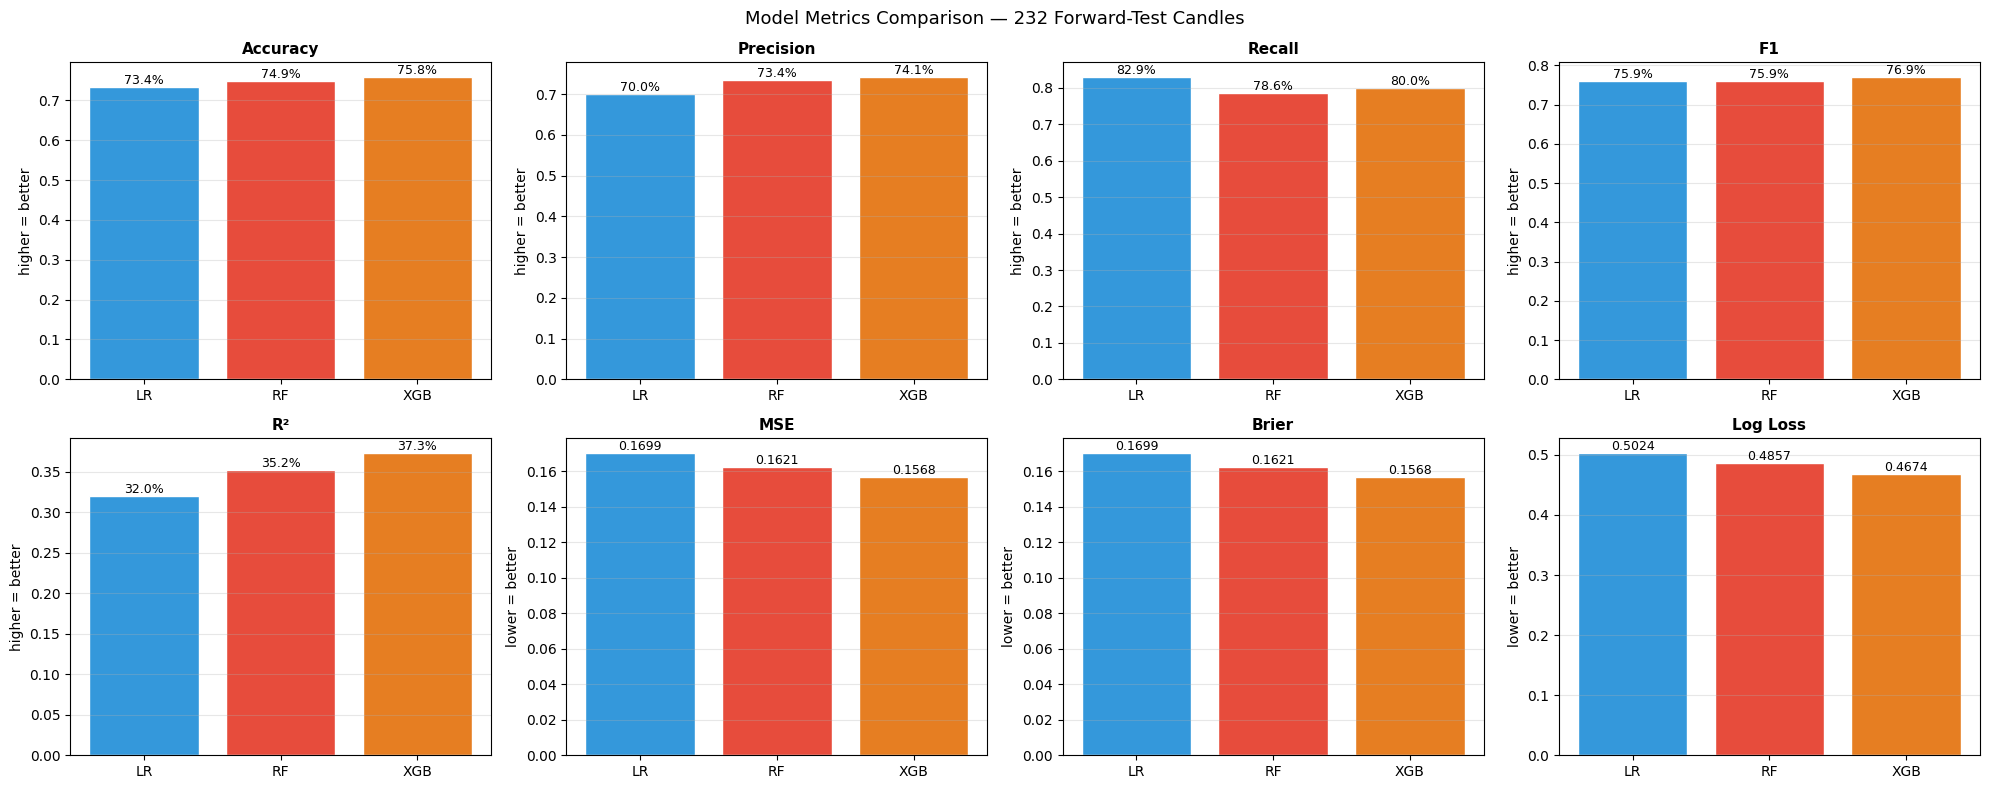

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
colors_map = {"LR": "#3498db", "RF": "#e74c3c", "XGB": "#e67e22"}
model_names = list(metrics_df.index)
bar_colors = [colors_map[m] for m in model_names]

for idx, col in enumerate(metrics_df.columns):
    ax = axes[idx]
    vals = metrics_df[col].values
    bars = ax.bar(model_names, vals, color=bar_colors, edgecolor="white")
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

    for bar, v in zip(bars, vals, strict=False):
        label = f"{v:.1%}" if col in ("Accuracy", "Precision", "Recall", "F1", "R²") else f"{v:.4f}"
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), label, ha="center", va="bottom", fontsize=9)

    # Arrow indicating which direction is better
    if col in ("MSE", "Brier", "Log Loss"):
        ax.set_ylabel("lower = better")
    else:
        ax.set_ylabel("higher = better")

plt.suptitle(f"Model Metrics Comparison — {len(all_cd)} Forward-Test Candles", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Inference speed

How fast can each model predict? This matters because the bot predicts on every snapshot (~1/sec).
A slow model adds latency between receiving market data and placing a bet.

**Metrics:**
- **Mean**: Average prediction time per snapshot. Tells you the typical cost.
- **P50 (median)**: The "normal" prediction time — 50% of predictions are faster than this.
- **P95**: 95th percentile — the "worst typical" case. 1 in 20 predictions will be slower. This is the number to watch: if P95 exceeds your tick interval (~1s), the model can't keep up.
- **P99**: 99th percentile — extreme tail. 1 in 100 predictions. Matters for detecting GC pauses or cold-cache effects.
- **Max**: Single worst prediction. Useful to spot if the model occasionally stalls.
- **Throughput**: Predictions per second. Must be >1 to keep up with the collector's snapshot rate.

**How to read**: Lower latency = better. P95 under 100ms is excellent. Over 500ms is a concern for live trading.


In [20]:
import time

latency = {key: [] for key in ["LR", "RF", "XGB"]}

for cd in tqdm(all_cd, desc="Benchmarking inference"):
    snap_rows = df_eval[df_eval["candle_id"] == cd["candle_id"]].sort_values("timestamp")
    if len(snap_rows) < 5:
        continue

    for key in ["LR", "RF", "XGB"]:
        m = models[key]
        X = m["scaler"].transform(snap_rows[m["feat_cols"]].values)

        # Time batch prediction (one candle's worth of snapshots — realistic usage)
        t0 = time.perf_counter()
        m["model"].predict_proba(X)
        elapsed_ms = (time.perf_counter() - t0) * 1000
        # Store per-snapshot average for this batch
        latency[key].append(elapsed_ms / len(X))

n_snapshots = sum(len(cd["snapshots"]) for cd in all_cd)
print(f"Benchmarked {len(all_cd)} candles ({n_snapshots:,} snapshots)\n")

print(f"{'Model':<6} {'Mean':>8} {'P50':>8} {'P95':>8} {'P99':>8} {'Max':>8} {'Throughput':>12}")
print("-" * 62)

speed_stats = {}
for key in ["LR", "RF", "XGB"]:
    arr = np.array(latency[key])
    stats = {
        "mean": np.mean(arr),
        "p50": np.percentile(arr, 50),
        "p95": np.percentile(arr, 95),
        "p99": np.percentile(arr, 99),
        "max": np.max(arr),
        "throughput": 1000 / np.mean(arr),
    }
    speed_stats[key] = stats
    print(
        f"{key:<6} {stats['mean']:>7.3f}ms {stats['p50']:>7.3f}ms {stats['p95']:>7.3f}ms "
        f"{stats['p99']:>7.3f}ms {stats['max']:>7.1f}ms {stats['throughput']:>10.0f}/s"
    )

Benchmarking inference: 100%|██████████| 232/232 [00:03<00:00, 64.82it/s]

Benchmarked 232 candles (10,936 snapshots)

Model      Mean      P50      P95      P99      Max   Throughput
--------------------------------------------------------------
LR       0.001ms   0.001ms   0.001ms   0.001ms     0.0ms    1336983/s
RF       0.280ms   0.279ms   0.293ms   0.321ms     0.8ms       3571/s
XGB      0.020ms   0.019ms   0.022ms   0.026ms     0.1ms      51103/s


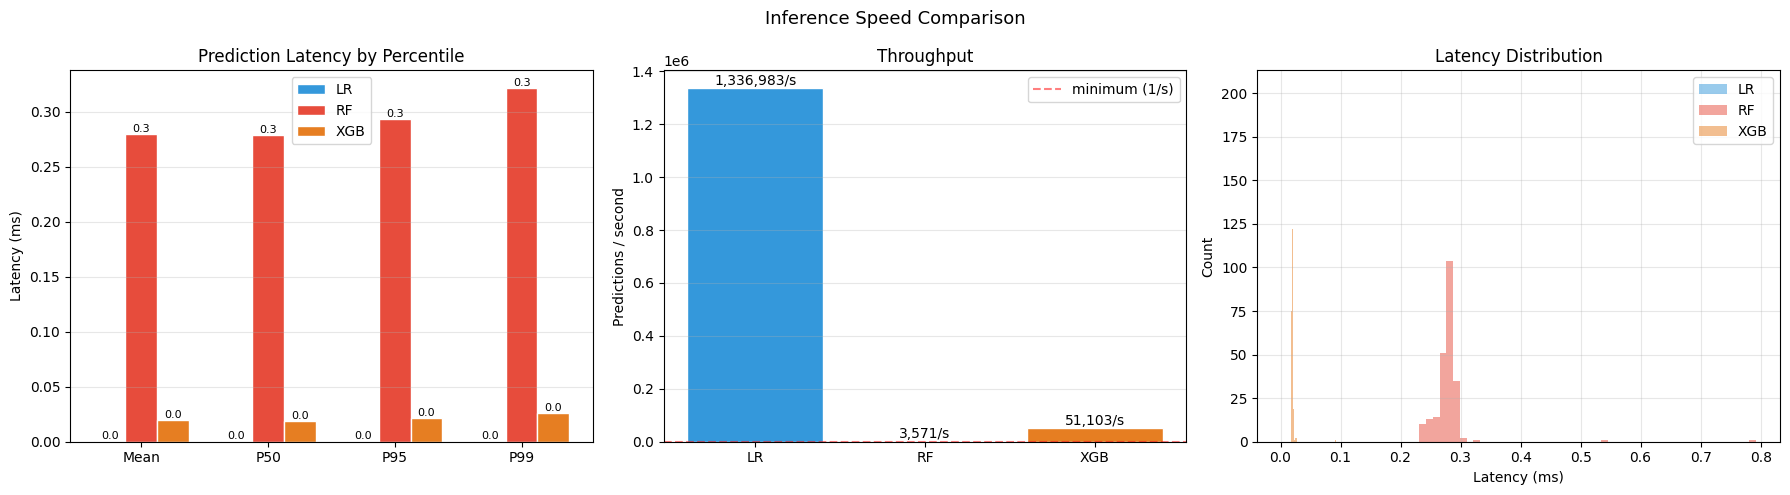

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_map = {"LR": "#3498db", "RF": "#e74c3c", "XGB": "#e67e22"}

# Chart 1: Latency percentiles (bar chart)
ax = axes[0]
metric_names = ["Mean", "P50", "P95", "P99"]
metric_keys = ["mean", "p50", "p95", "p99"]
x = np.arange(len(metric_names))
width = 0.25

for idx, key in enumerate(["LR", "RF", "XGB"]):
    vals = [speed_stats[key][k] for k in metric_keys]
    bars = ax.bar(x + idx * width, vals, width, label=key, color=colors_map[key], edgecolor="white")
    for bar, v in zip(bars, vals, strict=False):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{v:.1f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metric_names)
ax.set_ylabel("Latency (ms)")
ax.set_title("Prediction Latency by Percentile")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Chart 2: Throughput comparison
ax = axes[1]
throughputs = [speed_stats[key]["throughput"] for key in ["LR", "RF", "XGB"]]
bars = ax.bar(["LR", "RF", "XGB"], throughputs, color=[colors_map[k] for k in ["LR", "RF", "XGB"]], edgecolor="white")
for bar, v in zip(bars, throughputs, strict=False):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{v:,.0f}/s", ha="center", va="bottom", fontsize=10)
ax.axhline(1, color="red", linestyle="--", alpha=0.5, label="minimum (1/s)")
ax.set_ylabel("Predictions / second")
ax.set_title("Throughput")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Chart 3: Latency distribution (histogram)
ax = axes[2]
for key in ["LR", "RF", "XGB"]:
    ax.hist(latency[key], bins=50, alpha=0.5, label=key, color=colors_map[key])
ax.set_xlabel("Latency (ms)")
ax.set_ylabel("Count")
ax.set_title("Latency Distribution")
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle("Inference Speed Comparison", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Confidence vs Win Rate

How well-calibrated is each model? When it says 70% confident, does it actually win 70% of the time?

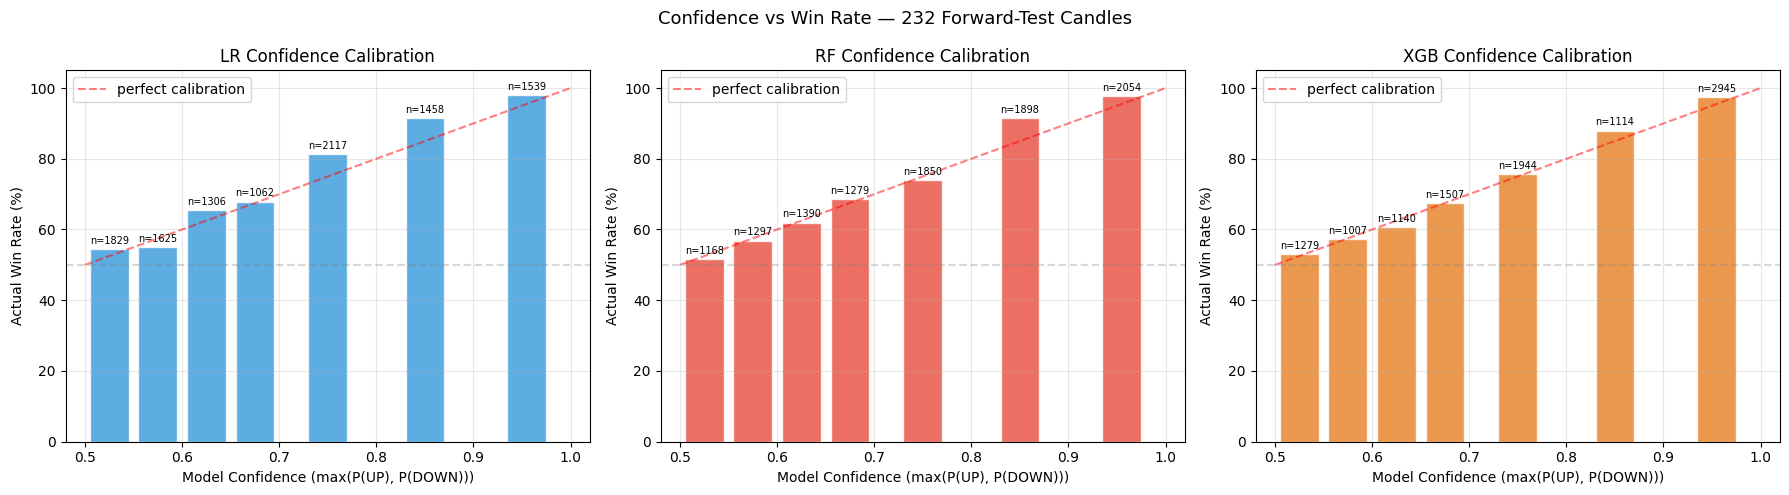

In [22]:
bins = [
    (0.50, 0.55),
    (0.55, 0.60),
    (0.60, 0.65),
    (0.65, 0.70),
    (0.70, 0.80),
    (0.80, 0.90),
    (0.90, 1.01),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_map = {"LR": "#3498db", "RF": "#e74c3c", "XGB": "#e67e22"}

for ax, model_key in zip(axes, ["LR", "RF", "XGB"], strict=False):
    pred_key = f"{model_key}_pred"
    prob_key = f"{model_key}_prob"

    cal_data = []
    for lo, hi in bins:
        correct_count = 0
        total_count = 0
        for cd in all_cd:
            for sd in cd["snapshots"]:
                confidence = max(sd[prob_key], 1.0 - sd[prob_key])
                if confidence >= lo and confidence < hi:
                    total_count += 1
                    if sd[pred_key] == cd["truth"]:
                        correct_count += 1
        if total_count == 0:
            continue
        wr = correct_count / total_count
        cal_data.append({"range": f"{lo:.2f}-{hi:.2f}", "n": total_count, "win_rate": wr, "mid": (lo + hi) / 2})

    if not cal_data:
        ax.set_title(f"{model_key} — no data")
        continue

    x = [d["mid"] for d in cal_data]
    wr = [d["win_rate"] * 100 for d in cal_data]
    ns = [d["n"] for d in cal_data]

    ax.bar(x, wr, width=0.04, color=colors_map[model_key], edgecolor="white", alpha=0.8)
    ax.plot([0.5, 1.0], [50, 100], "r--", alpha=0.5, label="perfect calibration")
    ax.axhline(50, color="gray", linestyle="--", alpha=0.3)
    ax.set_xlabel("Model Confidence (max(P(UP), P(DOWN)))")
    ax.set_ylabel("Actual Win Rate (%)")
    ax.set_title(f"{model_key} Confidence Calibration")
    ax.legend()
    ax.set_xlim(0.48, 1.02)
    ax.set_ylim(0, 105)
    ax.grid(alpha=0.3)

    for xi, wi, ni in zip(x, wr, ns, strict=False):
        ax.text(xi, wi + 1.5, f"n={ni}", ha="center", fontsize=7)

plt.suptitle(f"Confidence vs Win Rate — {len(all_cd)} Forward-Test Candles", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Equity curves

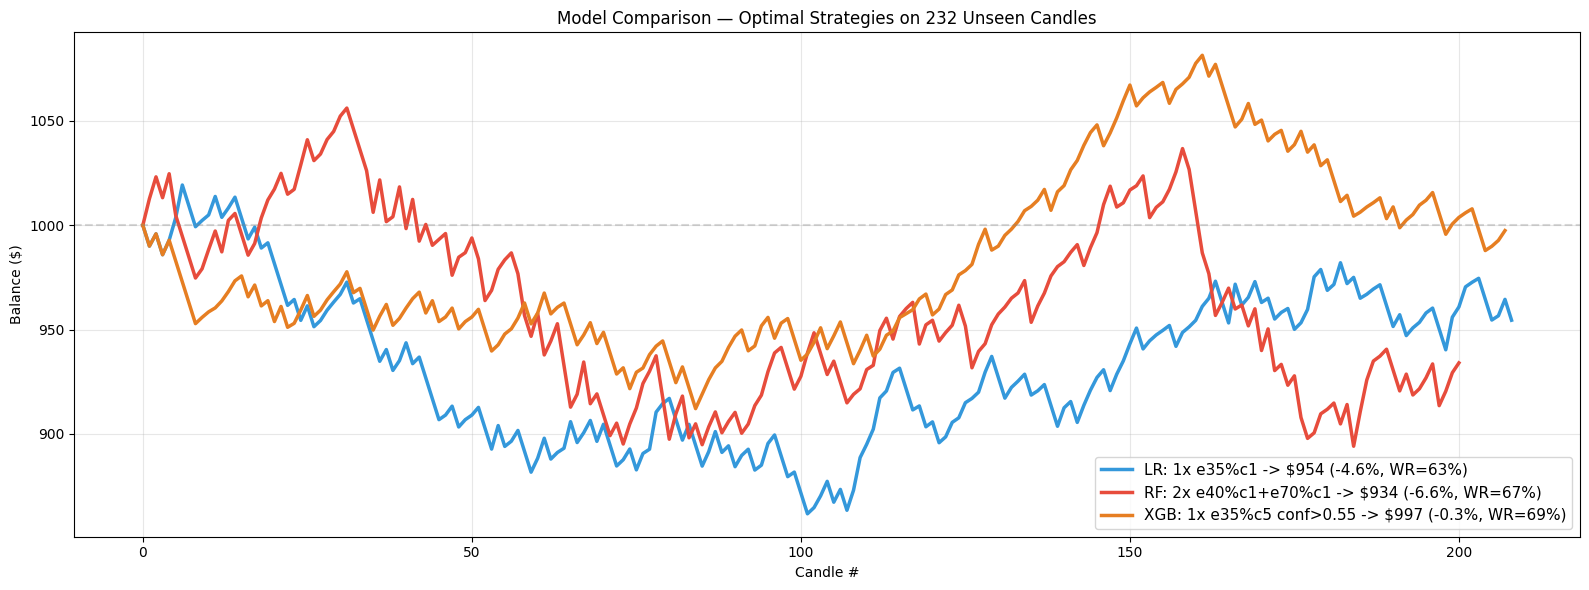

In [23]:
fig, ax = plt.subplots(figsize=(16, 6))

colors = {"LR": "#3498db", "RF": "#e74c3c", "XGB": "#e67e22"}
for key in ["LR", "RF", "XGB"]:
    r = results[key]
    s = strategies[key]
    ax.plot(
        r["history"],
        color=colors[key],
        linewidth=2.5,
        label=f"{key}: {s['strategy']} -> ${r['balance']:,.0f} ({r['return_pct']:+.1f}%, WR={r['win_rate'] * 100:.0f}%)",
    )

ax.axhline(1000, color="gray", linestyle="--", alpha=0.3)
ax.set_xlabel("Candle #")
ax.set_ylabel("Balance ($)")
ax.set_title(f"Model Comparison — Optimal Strategies on {len(all_cd)} Unseen Candles")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Summary

In [24]:
print("=" * 80)
print("MODEL COMPARISON — FORWARD TEST SUMMARY")
print(f"Candles: {len(all_cd)} (unseen during training)")
print("Models loaded from: models/ (pre-trained)")
print("Strategies loaded from: data/optimal_strategy_*.json")
print("=" * 80)

print(f"\n{'':20} {'LR':>20} {'RF':>20} {'XGB':>20}")
print("-" * 82)
for label, key in [
    ("Strategy", "strategy"),
    ("Win Rate", "win_rate"),
    ("Return", "return_pct"),
    ("Max Drawdown", "max_dd"),
    ("Final Balance", "balance"),
    ("Total Bets", "total_bets"),
]:
    vals = []
    for m in ["LR", "RF", "XGB"]:
        if key == "strategy":
            vals.append(strategies[m]["strategy"])
        elif key == "win_rate":
            vals.append(f"{results[m][key] * 100:.1f}%")
        elif key == "return_pct":
            vals.append(f"{results[m][key]:+.1f}%")
        elif key == "max_dd":
            vals.append(f"{results[m][key] * 100:.1f}%")
        elif key == "balance":
            vals.append(f"${results[m][key]:,.2f}")
        else:
            vals.append(str(results[m][key]))
    print(f"{label:<20} {vals[0]:>20} {vals[1]:>20} {vals[2]:>20}")

winner = max(results, key=lambda k: results[k]["balance"])
print(f"\nWinner: {winner}")
print("\nNote: Small sample size — results are directional, not conclusive.")
print("Re-run after collecting more data for robust comparison.")

MODEL COMPARISON — FORWARD TEST SUMMARY
Candles: 232 (unseen during training)
Models loaded from: models/ (pre-trained)
Strategies loaded from: data/optimal_strategy_*.json

                                       LR                   RF                  XGB
----------------------------------------------------------------------------------
Strategy                        1x e35%c1     2x e40%c1+e70%c1  1x e35%c5 conf>0.55
Win Rate                            63.0%                66.8%                69.1%
Return                              -4.6%                -6.6%                -0.3%
Max Drawdown                        15.5%                15.4%                 8.8%
Final Balance                     $954.46              $934.00              $997.44
Total Bets                            208                  292                  207

Winner: XGB

Note: Small sample size — results are directional, not conclusive.
Re-run after collecting more data for robust comparison.


## Conclusion

Each model ran its own optimal strategy (from `data/optimal_strategy_*.json`) on the same
unseen candles. No re-training, no strategy search — purely an execution comparison.

Re-run after updating models (`*/02_export`) or strategies (`*/03_strategy`).
